# WHaLE Example Usage and functionality

This notebook is purely for demonstration purposes on how to configure and use WHaLE. The first note is that a user's `library_path` should have three subfolders: "ORBIT", "WOMBAT", and "FLORIS", each setup in a way that aligns with the respective software's library specifications.

## Imports and environment set up

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from floris.tools.visualization import visualize_cut_plane

from whale import Project

pd.options.display.float_format = '{:,.4f}'.format

## Determine the configurations and create a Project

**NOTE**: Make sure in the WOMBAT config files that the library path is the same that gets printed in this first code block when you run the notebook

In [2]:
library_path = Path("library").resolve()
orbit_config = "example_fixed_project.yaml"
wombat_config = "base.yaml"
floris_config = "jensen.yaml"
print(library_path)

/Users/rhammond/Documents/GitHub/WHaLE/examples/library


In [3]:
project = Project(
    library_path=library_path,
    weather=library_path / "WOMBAT" / "weather" / "alpha_ventus_weather_2002_2014.csv",
    orbit_config=orbit_config,
    wombat_config=wombat_config,
    floris_config=floris_config,
)

ORBIT library intialized at '/Users/rhammond/Documents/GitHub/WHaLE/examples/library/ORBIT'


In [4]:
# show that everything is initialized
print(f"ORBIT Capacity: {project.orbit.capacity} MW")
print(f"WOMBAT Capacity: {project.wombat.windfarm.capacity / 1000:.0f} MW")
print(f"FLORIS coordinates: {list(zip(project.floris.layout_x, project.floris.layout_y))}")

ORBIT Capacity: 300 MW
WOMBAT Capacity: 240 MW
FLORIS coordinates: [(0.0, 0.0), (630.0, 0.0), (1260.0, 0.0)]


## Run the analyses and calculate results

This separately calls the `run` methods for each of the ORBIT `ProjectManager` and WOMBAT `Simualation`, in that order. Alternatively, these could just be called on their own, just like we must with FLORIS for the time being.

**NOTE: In reality, it will need to be determined how we should actually run FLORIS to get the outputs that we want, so this usage is a crude placeholder**

In [5]:
project.run_capex_opex()

project.floris.calculate_wake()

In [6]:
project.orbit.capex_breakdown

{'Array System': 24416575.834140003,
 'Export System': 22813500.0,
 'Offshore Substation': 49739550.0,
 'Scour Protection': 5896000,
 'Substructure': 154436243.91851607,
 'Array System Installation': 13977660.90384193,
 'Export System Installation': 62039979.67184249,
 'Offshore Substation Installation': 3409501.8236301374,
 'Scour Protection Installation': 15557481.164383564,
 'Substructure Installation': 25315113.672610253,
 'Turbine Installation': 41585747.71689493,
 'Turbine': 450000000,
 'Soft': 162948000.0,
 'Project': 151250000.0}

In [7]:
project.wombat.metrics.time_based_availability("project", "windfarm")

,windfarm
0,0.9613


In [8]:
# OpEx, in millions, annually
project.wombat.metrics.opex(frequency="annual") / 1e6

The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.FutureWarning: /opt/miniconda3/envs/whale/lib/python3.10/site-packages/wombat/core/post_processor.py:1721
The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.FutureWarning: /opt/miniconda3/envs/whale/lib/python3.10/site-packages/wombat/core/post_processor.py:774
The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.FutureWarning: /opt/miniconda3/envs/whale/lib/python3.10/site-packages/wombat/core/post_processor.py:1251
The default value of nu

,OpEx
year,
2003,16.0589
2004,13.8464
2005,20.6151
2006,14.3606
2007,16.9023
2008,5.5865
2009,23.7327
2010,13.1693
2011,12.0775


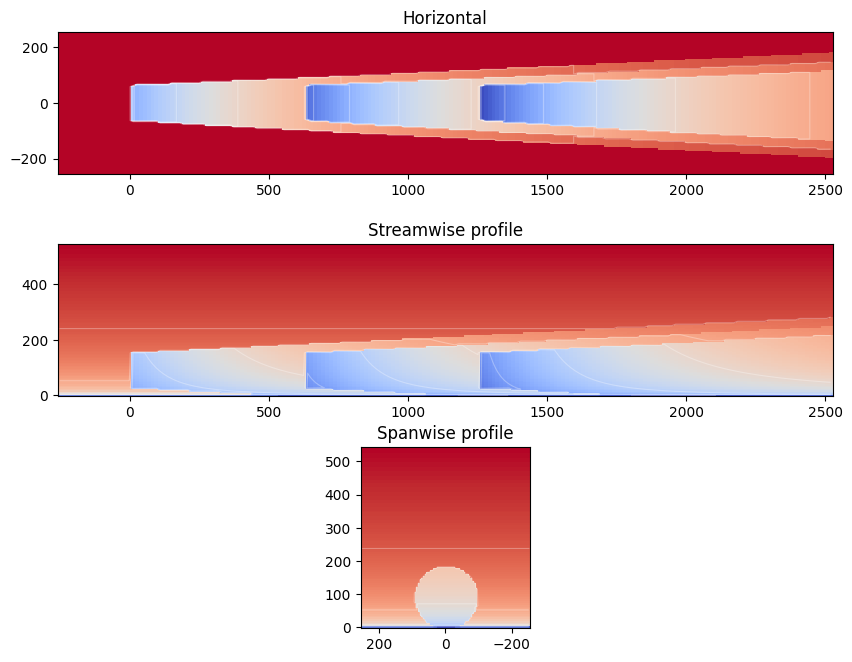

In [9]:
# From the FLORIS visualization example
horizontal_plane = project.floris.calculate_horizontal_plane(x_resolution=200, y_resolution=100, height=90.0)
y_plane = project.floris.calculate_y_plane(x_resolution=200, z_resolution=100, crossstream_dist=0.0)
cross_plane = project.floris.calculate_cross_plane(y_resolution=100, z_resolution=100, downstream_dist=630.0)


# Create the plots
fig, ax_list = plt.subplots(3, 1, figsize=(10, 8))
ax_list = ax_list.flatten()

# Plot each component
visualize_cut_plane(horizontal_plane, ax=ax_list[0], title="Horizontal")
visualize_cut_plane(y_plane, ax=ax_list[1], title="Streamwise profile")
visualize_cut_plane(cross_plane, ax=ax_list[2], title="Spanwise profile")

# Show the figures
plt.show()

In [ ]:
project.wombat.env.cleanup_log_filesanup_log_files()